# Bi-level оптимизация (SUE): автобусная сеть Кудрово → метро «Улица Дыбенко»

**Курсовая: «Моделирование маршрутов общественного транспорта … (пригороды Санкт-Петербурга)»**

## Что это и зачем — вариант B (полный bi-level со Stochastic User Equilibrium)
В прошлых ноутбуках нижний уровень был примитивным: пассажир детерминированно шёл на
**лучшую** из 3 ближайших остановок (`argmin`). Здесь нижний уровень — реалистичная **модель
поведения**:

1. **Выбор остановки вероятностный (logit).** Пассажир не привязан к лучшей остановке: чем
   привлекательнее остановка, тем выше вероятность, но часть людей идёт и на другие.
   Привлекательность остановки растёт с **числом маршрутов** через неё и их **качеством**
   (меньше ожидание) — ровно то, что предлагалось в задании.
2. **Несколько маршрутов на остановке складывают частоты.** Остановка, через которую идёт
   несколько маршрутов до метро, привлекательнее: ждать меньше (раньше придёт хоть один). Это
   «мультипликатор от числа и качества маршрутов» из задания — он влияет на выбор остановки.

Даже без учёта давки выбор не считается «в один проход»: привлекательность остановки зависит
от интервалов, интервалы — от раздачи парка, раздача парка — от потоков, а потоки — от выбора.
Этот круг разрешается поиском **неподвижной точки** — Stochastic User Equilibrium (SUE),
методом последовательных средних (MSA).

> **О провозимости.** Обратную связь по перегрузу (давка снижает привлекательность маршрута)
> модель умеет учитывать (флаг `crowd=True`), но в данной работе она **выключена**: фокус —
> оптимизация *маршрутов* в существующей сети, а не провозимость; к тому же население —
> приближённая (по жилплощади) величина, и абсолютные потоки заданы лишь в пропорциях. Как
> показано ниже, при `crowd=False` итоговая метрика `T_avg` **вообще не зависит** от
> масштаба спроса (доли коммьютеров) — она влияет только на иллюстративные цифры потока.

**Зачем это для работы.** `argmin`-модель даёт оптимистичную оценку (игнорирует и
разброс поведения, и давку). SUE показывает, что те же маршруты под реалистичным поведением
работают иначе, и заставляет оптимизатор **раскидывать нагрузку**, а не только сокращать
номинальное время. Это честный шаг к будущему GNN+RL: у RL должен быть реалистичный
симулятор пассажиров, иначе политика обучится играть в упрощённый мир.

## Архитектура (поток данных)
```
Данные (.gpkg, .csv) ──► граф автобусов, времена, спрос, пул кандидатов  (как раньше)
                                  │
   ВЕРХНИЙ УРОВЕНЬ:  Генетический алгоритм выбирает набор маршрутов     (как раньше)
                                  │ для каждого набора —
   НИЖНИЙ УРОВЕНЬ (НОВОЕ): Stochastic User Equilibrium
        ┌───────────────────────────────────────────────┐
        │  (a) стоимость остановки = оптимальная стратегия│ ◄─┐
        │      Спиесса-Флориана (учёт числа маршрутов)    │   │ MSA до
        │  (b) выбор остановки по logit                   │   │ неподвижной
        │  (c) потоки на маршрутах                         │   │ точки
        │  (раздача парка ↔ интервалы ↔ выбор)             │ ──┘
        └───────────────────────────────────────────────┘
                                  │
        фитнес = T_avg в равновесии  ──►  ГА минимизирует
```


## 1. Параметры
`P` — идентичны прежним ноутбуам. `GA` — гиперпараметры генетики (популяция меньше, т.к.
каждая оценка теперь дороже). `SUE` — параметры нижнего уровня (новое).

In [15]:
import json, numpy as np, pandas as pd, geopandas as gpd, networkx as nx
from shapely.geometry import LineString
from scipy.spatial import cKDTree
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
try: from IPython.display import display
except Exception: display = print

CRS = 32636

P = dict(
    walk_speed_mps   = 5*1000/3600, bus_cruise_kmh = 40, bus_speed_factor = 0.65,
    dwell_s = 29, layover_factor = 1.15,
    alpha_zan = 0.568, beta_vyezd = 0.7, gamma_ot = 0.565,
    k_shortest = 3, n_seeds = 44, max_routes = 8,
    unserved_penalty_s = 3600, peak_hours = 2.0,
    min_stops = 3, stop_dedup_m = 206,
)
P['commuter_share'] = P['alpha_zan']*P['beta_vyezd']*P['gamma_ot']   # ≈ 0.225 по модели Хаффа
P['commuter_share'] = 0.15   # скорректированная оценка доли коммьютеров на ОТ.
# ВАЖНО: при crowd=False (режим этой работы) T_avg НЕ зависит от этого числа — sqrt-правило
# раздачи парка инвариантно к масштабу спроса. commuter_share влияет лишь на иллюстративные
# абсолютные потоки/загрузки в таблицах, но не на оптимизируемую метрику.
print("commuter_share:", round(P['commuter_share'], 3))

# ── ГА (верхний уровень): меньше, т.к. фитнес теперь = равновесие ─────────────
GA = dict(pop_size=50, generations=60, elite=4, tournament=3,
          p_cross=0.85, p_mut=0.30, r_min=2, r_max=8, seed=42)

# ── SUE (нижний уровень) ─────────────────────────────────────────────────────
SUE = dict(
    theta     = 0.003,   # масштаб логита (1/сек): больше => выбор ближе к argmin
    w0        = 0.5,     # числитель ожидания: одиночный маршрут => ожидание = headway/2
    crowd_a   = 0.6,     # [опц., crowd=True] сила штрафа давки
    crowd_b   = 1.0,     # [опц., crowd=True] нелинейность штрафа по перегрузу
    crowd_cap = 2.0,     # [опц., crowd=True] потолок «избытка загрузки»
    msa_iters = 100,     # макс. итераций MSA
    msa_tol   = 1e-3,    # критерий сходимости (относительный зазор потоков)
)

def make_fleet(n_liaz, n_volga): return sorted([117]*n_liaz + [49]*n_volga, reverse=True)
FLEET = make_fleet(8, 10)
print("Парк:", len(FLEET), "машин, вместимость", sum(FLEET), "чел/рейс")

# ── ПУТИ (зеркалят бейзлайн; поправьте под свои папки) ───────────────────────
PATHS = dict(
    roads    = r"C:\Users\georg\NIS\Curse_work_2026\kud_roads_buses_v3.gpkg",
    stops    = r"C:\Users\georg\NIS\Curse_work_2026\bus_stops_v2.gpkg",
    ent      = r"C:/Users/georg/Downloads/paradniye_with_pop_v2.gpkg",
    od       = r"C:\Users\georg\NIS\od_matrix_topk.csv",
    existing = r"C:\Users\georg\Documents\kud_routes.gpkg",
    out      = r"C:\Users\georg\NIS\Curse_work_2026\sue_routes_v2.gpkg",
)

commuter_share: 0.15
Парк: 18 машин, вместимость 1426 чел/рейс


## 2. Граф автобусной сети (как раньше)

In [16]:
def parse_maxspeed(v, d):
    if v is None or (isinstance(v,float) and np.isnan(v)): return d
    s=str(v)
    if s=='RU:urban': return 60
    try: return float(s.split()[0])
    except: return d

def build_bus_graph(roads_gpkg, layer='doroga_for_busiki'):
    gdf = gpd.read_file(roads_gpkg, layer=layer).to_crs(CRS).explode(index_parts=False)
    G = nx.DiGraph()
    for _, row in gdf.iterrows():
        g=row.geometry
        if g is None or g.is_empty: continue
        v = parse_maxspeed(row.get('maxspeed'), P['bus_cruise_kmh'])*P['bus_speed_factor']*1000/3600
        oneway = (row.get('oneway')=='yes'); c=list(g.coords)
        for i in range(len(c)-1):
            u=(round(c[i][0],1),round(c[i][1],1)); w=(round(c[i+1][0],1),round(c[i+1][1],1))
            if u==w: continue
            L=LineString([c[i],c[i+1]]).length
            G.add_edge(u,w,length=L,time=L/v)
            if not oneway: G.add_edge(w,u,length=L,time=L/v)
    return G.subgraph(max(nx.strongly_connected_components(G), key=len)).copy()

G = build_bus_graph(PATHS['roads'])
print("Граф:", G.number_of_nodes(), "узлов,", G.number_of_edges(), "рёбер")

Граф: 1385 узлов, 2709 рёбер


## 3. Спрос, пешие времена, маппинг stop_id голосованием (как раньше)

In [17]:
ent = gpd.read_file(PATHS['ent']).to_crs(CRS).reset_index(drop=True)
ent['entrance_id'] = ent.index + 1
ent_pop = ent.set_index('entrance_id')['population']
stops = gpd.read_file(PATHS['stops']).to_crs(CRS).reset_index(drop=True)
is_metro = stops['name'].astype(str).str.contains('Дыбенко', na=False)
board = stops[~is_metro].reset_index(drop=True)
metro = stops[is_metro].reset_index(drop=True)

od = pd.read_csv(PATHS['od'])
sxy = np.c_[board.geometry.x, board.geometry.y]; exy = np.c_[ent.geometry.x, ent.geometry.y]
_, eidx = cKDTree(sxy).query(exy, k=3)
votes = defaultdict(Counter); od_by_ent = od.groupby('entrance_id')['stop_id'].apply(list)
for eid in range(1, len(ent)+1):
    for r, sid in enumerate(od_by_ent.get(eid, [])):
        if r < 3: votes[sid][int(eidx[eid-1][r])] += 1
stopid_map = {sid: cnt.most_common(1)[0][0] for sid, cnt in votes.items()}
bad = sum(1 for _, row in od.iterrows() if row['stop_id'] in stopid_map and
          ent.iloc[row['entrance_id']-1].geometry.distance(board.iloc[stopid_map[row['stop_id']]].geometry) > row['walk_dist_m']+1)
print(f"Подъездов {len(ent)}, остановок {len(board)}, метро {len(metro)} | маппинг нарушений: {bad}")
od = od[od['stop_id'].isin(stopid_map)].copy()
od['board_idx'] = od['stop_id'].map(stopid_map)
od['t_walk'] = od['walk_dist_m'] / P['walk_speed_mps']

Подъездов 621, остановок 44, метро 7 | маппинг нарушений: 0


## 4. Времена по графу (как раньше)

In [18]:
board_nodes = [list(G.nodes)[k] for k in cKDTree(np.array(list(G.nodes))).query(np.c_[board.geometry.x, board.geometry.y])[1]]
metro_nodes = [list(G.nodes)[k] for k in cKDTree(np.array(list(G.nodes))).query(np.c_[metro.geometry.x, metro.geometry.y])[1]]
Grev = G.reverse(copy=False); dist_from_metro = {}
for mn in set(metro_nodes):
    for node, d in nx.single_source_dijkstra_path_length(Grev, mn, weight='time').items():
        if d < dist_from_metro.get(node, 1e18): dist_from_metro[node] = d
n = len(board)
t_to_metro = np.array([dist_from_metro.get(board_nodes[i], np.inf) for i in range(n)])
t_between = np.full((n, n), np.inf)
cache = {sn: nx.single_source_dijkstra_path_length(G, sn, weight='time') for sn in set(board_nodes)}
for i, bi in enumerate(board_nodes):
    for j, bj in enumerate(board_nodes): t_between[i, j] = cache[bi].get(bj, np.inf)
print(f"Остановок с временем до метро: {np.isfinite(t_to_metro).sum()}/{n}")

Остановок с временем до метро: 44/44


## 5. Пул кандидатов (k-кратчайших + существующие, с dedup — как в бейзлайне)

In [19]:
# Схлопывает соседние остановки маршрута ближе P['stop_dedup_m'] м (артефакт снэппинга).
def dedup_seq(seq):
    if not seq: return seq
    bxy = np.c_[board.geometry.x.values, board.geometry.y.values]; out=[seq[0]]
    for s in seq[1:]:
        if np.hypot(*(bxy[s]-bxy[out[-1]])) < P['stop_dedup_m']: continue
        out.append(s)
    return out

def route_oneway_time(r):
    if not r: return np.inf
    return sum(t_between[a,b] for a,b in zip(r[:-1],r[1:])) + t_to_metro[r[-1]]

demand_stop = np.zeros(len(board))
for eid, grp in od[od['rank']==1].groupby('entrance_id'):
    demand_stop[int(grp.iloc[0]['board_idx'])] += ent_pop.get(eid, 0)
btree = cKDTree(np.array(board_nodes)); target = metro_nodes[0]
seeds = sorted(range(len(board)), key=lambda i: -(demand_stop[i]*(t_to_metro[i] if np.isfinite(t_to_metro[i]) else 0)))[:P['n_seeds']]
cands = []
for s in seeds:
    try: paths = nx.shortest_simple_paths(G, board_nodes[s], target, weight='time')
    except nx.NetworkXNoPath: continue
    for k, path in enumerate(paths):
        if k >= P['k_shortest']: break
        seq, seen = [], set()
        for node in path:
            d, bi = btree.query(node, k=1)
            if d < 30 and int(bi) not in seen: seq.append(int(bi)); seen.add(int(bi))
        seq = dedup_seq(seq)
        if len(seq) >= P['min_stops']: cands.append(seq)
def load_existing():
    bt2 = cKDTree(np.c_[board.geometry.x, board.geometry.y]); out=[]
    for src, layer in [(PATHS['existing'],'existing_routes'), ('OUTPUT.gpkg','existing_routes'), ('avtobus_marshruty.gpkg','autobudd')]:
        try: er = gpd.read_file(src, layer=layer).to_crs(CRS)
        except Exception: continue
        for _, row in er.iterrows():
            g=row.geometry
            if g is None: continue
            coords=[c for gg in (g.geoms if g.geom_type=='MultiLineString' else [g]) for c in gg.coords]
            seq, seen=[], set()
            for (x,y) in coords:
                d, bi = bt2.query([x,y], k=1)
                if d<60 and int(bi) not in seen: seq.append(int(bi)); seen.add(int(bi))
            seq = dedup_seq(seq)
            if len(seq) >= P['min_stops']: out.append(seq)
        if out: print(f"Существующие из {src} ({layer}): {len(out)}"); return out
    print("Существующие не найдены"); return []
existing_pool = load_existing(); cands += existing_pool
seen=set(); pool=[]
for r in cands:
    if tuple(r) not in seen: seen.add(tuple(r)); pool.append(r)
print(f"Кандидатов в пуле: {len(pool)} (существующих: {len(existing_pool)})")

Существующие из C:\Users\georg\Documents\kud_routes.gpkg (existing_routes): 4
Кандидатов в пуле: 32 (существующих: 4)


## 6. Старый фитнес `argmin` (оставляем для сравнения)
Это нижний уровень из прошлых ноутбуков: пассажир идёт на лучшую обслуживаемую остановку,
давка учитывается грубым `overflow`-штрафом. Нужен как **базовая точка**: сравним сеть,
оптимальную под `argmin`, с сетью, оптимальной под SUE.

In [20]:
odr = od.sort_values(['entrance_id','rank']); E = odr['entrance_id'].nunique()
B_IDX = odr['board_idx'].values.astype(int).reshape(E, 3)
TWALK = odr['t_walk'].values.reshape(E, 3)
EIDS  = odr['entrance_id'].values.reshape(E, 3)[:, 0]
POP   = np.array([ent_pop.get(e, 0) for e in EIDS]); nstops = len(board)

def precompute_route(r):
    out = {}
    for pos, s in enumerate(r):
        suf = r[pos:]
        out[s] = sum(t_between[a,b] + P['dwell_s'] for a,b in zip(suf[:-1], suf[1:])) + t_to_metro[suf[-1]]
    return out

def evaluate_argmin(routes, detail=False):
    if not routes: return (np.inf, None) if detail else np.inf
    inv = np.full(nstops, np.inf); invr = np.full(nstops, -1, int)
    for rid, r in enumerate(routes):
        for s, t in precompute_route(r).items():
            if t < inv[s]: inv[s] = t; invr[s] = rid
    cov = invr >= 0; cr = cov[B_IDX]; first = np.argmax(cr, axis=1); has = cr.any(axis=1)
    chosen = B_IDX[np.arange(E), first]; flow = np.zeros(len(routes))
    for k in range(E):
        if has[k]: flow[invr[chosen[k]]] += POP[k]*P['commuter_share']
    fph = flow/P['peak_hours']; w = np.sqrt(np.maximum(fph,1)); nal = np.maximum(1, np.round(w/w.sum()*len(FLEET)).astype(int))
    while nal.sum()>len(FLEET): nal[np.argmax(nal)]-=1
    while nal.sum()<len(FLEET): nal[np.argmax(fph)]+=1
    cyc = np.array([2*route_oneway_time(r)*P['layover_factor'] for r in routes])
    head = cyc/np.maximum(nal,1)
    wait = np.where(cov, head[invr]/2, np.inf)
    OPT = np.where(cov[B_IDX], TWALK + wait[B_IDX] + inv[B_IDX], np.inf)
    et = OPT.min(axis=1); et = np.where(np.isfinite(et), et, P['unserved_penalty_s'])
    Tavg = float((POP*et).sum()/POP.sum())
    if detail: return Tavg, dict(served_pct=float(POP[has].sum()/POP.sum()*100), ent_time=et)
    return Tavg

## 7. Нижний уровень: Stochastic User Equilibrium — **обоснование каждого шага**

### 7.1 Стоимость остановки = «оптимальная стратегия» Спиесса-Флориана (1989)
**Зачем.** Задание требует, чтобы привлекательность остановки зависела от **числа маршрутов** и
их **качества**. Наивно было бы взять минимум времени по маршрутам — но это игнорирует, что
несколько маршрутов через одну остановку **снижают ожидание** (раньше придёт хоть один). Модель
оптимальной стратегии формализует это: пассажир на остановке садится в **первый пришедший** из
«разумного» множества маршрутов. Стоимость остановки:
$$C_s = \frac{w_0 + \sum_{r\in A} f_r\,t_r}{\sum_{r\in A} f_r},$$
где $f_r=1/\text{интервал}_r$ — частота, $t_r$ — время в салоне до метро по маршруту $r$,
$A$ — множество «привлекательных» маршрутов. Числитель $w_0$ задаёт ожидание: для одного
маршрута $C_s = w_0/f_r + t_r = $ (ожидание $=$ интервал/2 при $w_0{=}0.5$) $+$ время в пути —
ровно как в прошлых ноутбуках. Множество $A$ строим жадно: добавляем маршруты по возрастанию
$t_r$, пока это **снижает** $C_s$. Так лишние медленные маршруты не портят остановку, а
несколько быстрых — улучшают. Это и есть «мультипликатор от числа и качества маршрутов»,
но выведенный из теории, а не назначенный руками.

### 7.2 Выбор остановки — logit
**Зачем.** Реальные люди не идут строго на лучшую остановку: кто-то выберет чуть худшую (ближе,
привычнее). Это разброс поведения. Вероятность выбора остановки $s$ подъездом $e$:
$$P_{e\to s} = \frac{e^{-\theta\,U_{es}}}{\sum_{s'} e^{-\theta\,U_{es'}}},\quad
U_{es} = t^{walk}_{es} + C_s.$$
Параметр $\theta$ — «решительность»: большой $\theta$ → выбор почти как `argmin`; малый → люди
сильнее размазаны. Это та же логит-логика, что в OD-весах по расстоянию и в гравитационной
модели Хаффа вашего научрука, но теперь полезность включает ещё и качество транзита $C_s$.

### 7.3 (опционально) Перегруз → штраф давки — В ЭТОЙ РАБОТЕ ВЫКЛЮЧЕН (crowd=False)
**В этой работе механизм выключен (`crowd=False`).** Код его поддерживает: штраф ко времени
маршрута, растущий с загрузкой,
$$\text{pen}_r = a\cdot t^{ride}_r \cdot \big(\min(\text{load}_r-1,\,\text{cap})\big)^{b}_+ ,$$
делает перегруженные маршруты менее привлекательными, и тогда выбор зависит от потока, а поток
— от выбора (полноценная capacity-обратная связь). Мы его не используем по двум причинам:
(1) исследование про оптимизацию *маршрутов*, а не про провозимость; (2) население —
приближённая (по жилплощади) величина в пропорциях, поэтому абсолютная загрузка ненадёжна, а
при `crowd=False` метрика `T_avg` от масштаба спроса не зависит вовсе. Включить можно одной
строкой (`crowd=True`) — это самостоятельный сценарий для будущей работы.

### 7.4 Поиск равновесия — метод последовательных средних (MSA)
**Зачем.** Даже без давки нет формулы «в один проход»: привлекательность остановки зависит от
интервалов, интервалы — от раздачи парка (sqrt-правило), раздача — от потоков, потоки — от
выбора. Это замкнутый круг → нужна **неподвижная точка**.
MSA (Sheffi, 1985): на итерации $k$ считаем «желаемые» потоки $y^k$ при текущих издержках, затем
сглаживаем: $x^{k+1} = x^k + \tfrac{1}{k}(y^k - x^k)$. Шаг $1/k$ гарантирует затухание
колебаний и сходимость. Останавливаемся, когда относительное изменение потоков $<$ `msa_tol`.
Раздачу парка (sqrt-правило) тоже пересчитываем внутри цикла по сглаженным потокам —
тогда «парк↔поток↔выбор» приходят в согласие одновременно.

In [21]:
def precompute_route_times(routes):
    pr = []
    for r in routes:
        d = {}
        for pos, s in enumerate(r):
            suf = r[pos:]
            d[s] = sum(t_between[a,b] + P['dwell_s'] for a,b in zip(suf[:-1], suf[1:])) + t_to_metro[suf[-1]]
        pr.append(d)
    return pr

# Нижний уровень = Stochastic User Equilibrium через MSA. Возвращает T_avg в равновесии
# (+ детали). crowd=False отключает давку (= вариант A для сравнения).
def evaluate_sue(routes, crowd=False, detail=False):   # crowd выключен: см. раздел 0
    if not routes: return (np.inf, None) if detail else np.inf
    K = len(routes); pr = precompute_route_times(routes)
    inveh0 = np.array([route_oneway_time(r) for r in routes])
    stop_routes = defaultdict(list)
    for rid, d in enumerate(pr):
        for s, t in d.items(): stop_routes[s].append((rid, t))
    cyc = np.array([2*route_oneway_time(r)*P['layover_factor'] for r in routes])
    seats_avg = sum(FLEET)/len(FLEET)
    Nveh = np.maximum(1, np.full(K, len(FLEET)//K))
    while Nveh.sum() > len(FLEET): Nveh[np.argmax(Nveh)] -= 1
    while Nveh.sum() < len(FLEET): Nveh[np.argmin(Nveh)] += 1
    route_flow = np.zeros(K); gaps = []; prob=None; has=None; U=None; served=None; it=0
    for it in range(1, SUE['msa_iters']+1):
        headway = cyc/np.maximum(Nveh,1); freq = 1.0/headway
        cap_period = Nveh*seats_avg*(3600.0/cyc)*P['peak_hours']
        load = np.where(cap_period>0, route_flow/np.maximum(cap_period,1), 0)
        if crowd:
            exc = np.clip(load-1, 0, SUE['crowd_cap'])
            pen = SUE['crowd_a']*inveh0*np.power(exc, SUE['crowd_b'])
        else:
            pen = np.zeros(K)
        # (7.1) стоимость остановки + распределение посадки по маршрутам
        stop_cost = np.full(nstops, np.inf); board_split = {}
        for s, lst in stop_routes.items():
            items = sorted([(t+pen[rid], rid) for rid, t in lst])
            f=0.0; ft=0.0; bestC=np.inf; chosen=[]
            for teff, rid in items:
                f2=f+freq[rid]; ft2=ft+freq[rid]*teff; C=(SUE['w0']+ft2)/f2
                if C <= bestC+1e-9: bestC=C; f=f2; ft=ft2; chosen.append(rid)
                else: break
            stop_cost[s]=bestC; fs=sum(freq[r] for r in chosen)
            board_split[s]={r: freq[r]/fs for r in chosen}
        # (7.2) logit-выбор остановки
        U = np.full((E,3), np.inf)
        for c in range(3): U[:,c] = TWALK[:,c] + stop_cost[B_IDX[:,c]]
        served = np.isfinite(U)
        shift = np.nanmin(np.where(served,U,np.nan), axis=1, keepdims=True)
        ex = np.where(served, np.exp(-SUE['theta']*(U-shift)), 0.0); Z = ex.sum(axis=1, keepdims=True)
        prob = np.where(Z>0, ex/Z, 0.0); has = (Z[:,0]>0)
        # потоки: подъезд -> остановки -> маршруты
        demand = POP*P['commuter_share']; stop_in = np.zeros(nstops)
        for c in range(3): np.add.at(stop_in, B_IDX[:,c], demand*prob[:,c])
        aux = np.zeros(K)
        for s, split in board_split.items():
            for r, p in split.items(): aux[r] += stop_in[s]*p
        # (7.4) MSA-сглаживание
        step = 1.0/it; new = route_flow + step*(aux-route_flow)
        gap = np.sum(np.abs(new-route_flow))/max(np.sum(new),1); route_flow = new; gaps.append(gap)
        # раздача парка по сглаженным потокам (sqrt-правило)
        w = np.sqrt(np.maximum(route_flow/P['peak_hours'],1)); Nveh = np.maximum(1, np.round(w/w.sum()*len(FLEET)).astype(int))
        while Nveh.sum() > len(FLEET): Nveh[np.argmax(Nveh)] -= 1
        while Nveh.sum() < len(FLEET): Nveh[np.argmax(route_flow)] += 1
        if gap < SUE['msa_tol'] and it > 5: break
    # ожидаемое (по выбору) время поездки подъезда
    et = np.where(has, (prob*np.where(served,U,0)).sum(axis=1), P['unserved_penalty_s'])
    Tavg = float((POP*et).sum()/POP.sum())
    headway = cyc/np.maximum(Nveh,1)
    cap_period = Nveh*seats_avg*(3600.0/cyc)*P['peak_hours']; load = route_flow/np.maximum(cap_period,1)
    # назначение типов машин (большие — нагруженным) для отчётности
    veh = {i: [] for i in range(K)}; ptr=0; fl=list(FLEET)
    for i in np.argsort(-route_flow):
        for _ in range(int(Nveh[i])):
            if ptr < len(fl): veh[i].append(fl[ptr]); ptr += 1
    if detail:
        return Tavg, dict(served_pct=float(POP[has].sum()/POP.sum()*100), ent_time=et,
                          route_flow=route_flow, Nveh=Nveh, load=load, gaps=gaps, iters=it,
                          headway=headway, flow_per_hour=route_flow/P['peak_hours'],
                          cap=cap_period/P['peak_hours'], veh=veh,
                          avg_maxprob=float(prob.max(axis=1)[has].mean()))
    return Tavg

## 8. Проверка нижнего уровня: сходимость MSA и поведение пассажиров
Берём жадно собранный под SUE набор и смотрим: (1) как MSA сходится (зазор потоков падает),
(2) насколько пассажиры «размазаны» по остановкам (средняя макс-вероятность выбора; 1.0 = как
argmin), (3) во сколько обходится сам факт стохастичности выбора (логит против почти-
детерминированного выбора при большом θ).

C:\Users\georg\AppData\Local\Temp\ipykernel_29432\1247505794.py:50: RuntimeWarning: All-NaN slice encountered
  shift = np.nanmin(np.where(served,U,np.nan), axis=1, keepdims=True)
C:\Users\georg\AppData\Local\Temp\ipykernel_29432\1247505794.py:52: RuntimeWarning: invalid value encountered in divide
  prob = np.where(Z>0, ex/Z, 0.0); has = (Z[:,0]>0)


Жадный под SUE: T_avg = 14.06 мин, маршрутов 8, обслужено 100.0%
MSA сошёлся за 16 итераций
Средняя макс-вероятность выбора: 0.83  (1.0 = argmin; <1 = размазывание)
Загрузки маршрутов: [2.47 2.69 1.21 1.47 1.95 1.06 2.03 1.06]  (макс 2.69; >1 = перегруз)
Почти-детерминированный выбор (большое θ): 13.65 мин | логит: 14.06 мин
Цена стохастичности выбора (часть людей идёт не на лучшую остановку): +0.41 мин


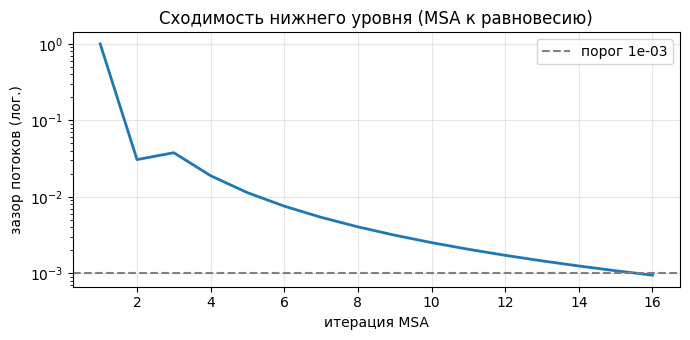

In [22]:
def greedy(evalfn):
    sel, best, improving = [], np.inf, True
    while improving and len(sel) < P['max_routes']:
        improving, best_add = False, None
        for c in pool:
            if c in sel: continue
            T = evalfn(sel+[c])
            if T < best-1e-6: best, best_add, improving = T, c, True
        if best_add is not None: sel.append(best_add)
    return sel, best

g_sue, T_sue = greedy(evaluate_sue)
_, d = evaluate_sue(g_sue, detail=True)
print(f"Жадный под SUE: T_avg = {T_sue/60:.2f} мин, маршрутов {len(g_sue)}, обслужено {d['served_pct']:.1f}%")
print(f"MSA сошёлся за {d['iters']} итераций")
print(f"Средняя макс-вероятность выбора: {d['avg_maxprob']:.2f}  (1.0 = argmin; <1 = размазывание)")
print(f"Загрузки маршрутов: {np.round(d['load'],2)}  (макс {d['load'].max():.2f}; >1 = перегруз)")
th0 = SUE['theta']; SUE['theta'] = 5.0          # большое θ => выбор почти детерминированный
T_det = evaluate_sue(g_sue); SUE['theta'] = th0
print(f"Почти-детерминированный выбор (большое θ): {T_det/60:.2f} мин | логит: {T_sue/60:.2f} мин")
print(f"Цена стохастичности выбора (часть людей идёт не на лучшую остановку): {(T_sue-T_det)/60:+.2f} мин")

plt.figure(figsize=(7,3.5))
plt.semilogy(range(1,len(d['gaps'])+1), d['gaps'], lw=2)
plt.axhline(SUE['msa_tol'], ls='--', color='gray', label=f"порог {SUE['msa_tol']:.0e}")
plt.xlabel('итерация MSA'); plt.ylabel('зазор потоков (лог.)')
plt.title('Сходимость нижнего уровня (MSA к равновесию)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Верхний уровень: генетический алгоритм над SUE
ГА тот же, что в прошлом ноутбуке (хромосома = подмножество пула, турнир, кроссовер по
множествам, мутация, элитизм), но фитнес = `evaluate_sue` (равновесие). Тёплый старт —
жадным под SUE решением, чтобы ГА не оказался хуже жадности.

In [23]:
def run_ga(evalfn, seed=None, warm=None, verbose=True):
    rng = np.random.default_rng(GA['seed'] if seed is None else seed); Npool = len(pool)
    def fit(ch): return evalfn([pool[i] for i in ch])
    def rand_ch():
        k = int(rng.integers(GA['r_min'], GA['r_max']+1)); return sorted(rng.choice(Npool, k, replace=False).tolist())
    def init_pop():
        pp = []
        if warm:
            ws = sorted({pool.index(r) for r in warm if r in pool})
            if len(ws) >= GA['r_min']: pp.append(ws)
        es = sorted({pool.index(r) for r in existing_pool if r in pool})[:GA['r_max']]
        if len(es) >= GA['r_min']: pp.append(es)
        while len(pp) < GA['pop_size']: pp.append(rand_ch())
        return pp
    def tour(pop, fits):
        idx = rng.integers(0, len(pop), GA['tournament']); return pop[idx[int(np.argmin([fits[i] for i in idx]))]]
    def cross(a, b):
        u = list(set(a)|set(b)); rng.shuffle(u); ch=[g for g in u if rng.random()<0.5]
        if len(ch) < GA['r_min']: ch = u[:GA['r_min']]
        if len(ch) > GA['r_max']: ch = ch[:GA['r_max']]
        return sorted(set(ch))
    def mut(ch):
        s=set(ch); op=int(rng.integers(0,3))
        if op==0 and len(s)<GA['r_max']: s.add(int(rng.integers(0,Npool)))
        elif op==1 and len(s)>GA['r_min']: s.discard(int(rng.choice(list(s))))
        else:
            if len(s)>GA['r_min']: s.discard(int(rng.choice(list(s))))
            s.add(int(rng.integers(0,Npool)))
        return sorted(s)
    pop = init_pop(); fits = [fit(c) for c in pop]; hist = []
    for gen in range(GA['generations']):
        order = np.argsort(fits); newp = [pop[order[i]] for i in range(GA['elite'])]
        while len(newp) < GA['pop_size']:
            p1=tour(pop,fits); p2=tour(pop,fits)
            ch = cross(p1,p2) if rng.random()<GA['p_cross'] else sorted(set(p1))
            if rng.random()<GA['p_mut']: ch = mut(ch)
            if len(ch)<GA['r_min']: ch = rand_ch()
            newp.append(ch)
        pop=newp; fits=[fit(c) for c in pop]; hist.append(min(fits))
        if verbose and (gen%15==0 or gen==GA['generations']-1):
            print(f"  поколение {gen:3d} | лучший T_avg = {min(fits)/60:.2f} мин")
    bi=int(np.argmin(fits)); return [pool[i] for i in pop[bi]], fits[bi], hist

import time
t0=time.time()
sel_sue, T_ga_sue, hist = run_ga(evaluate_sue, warm=g_sue)
print(f"\nГА под SUE: T_avg = {T_ga_sue/60:.2f} мин, маршрутов {len(sel_sue)}, время {time.time()-t0:.0f} c")

C:\Users\georg\AppData\Local\Temp\ipykernel_29432\1247505794.py:50: RuntimeWarning: All-NaN slice encountered
  shift = np.nanmin(np.where(served,U,np.nan), axis=1, keepdims=True)
C:\Users\georg\AppData\Local\Temp\ipykernel_29432\1247505794.py:52: RuntimeWarning: invalid value encountered in divide
  prob = np.where(Z>0, ex/Z, 0.0); has = (Z[:,0]>0)


  поколение   0 | лучший T_avg = 14.12 мин
  поколение  15 | лучший T_avg = 13.72 мин
  поколение  30 | лучший T_avg = 13.70 мин
  поколение  45 | лучший T_avg = 13.61 мин
  поколение  59 | лучший T_avg = 13.61 мин

ГА под SUE: T_avg = 13.61 мин, маршрутов 5, время 7 c


## 10. Главное сравнение: оптимизация под argmin vs под SUE
Ключевой вопрос работы: меняется ли решение, когда учитываем поведение пассажиров (вероятностный выбор остановки + выгода от нескольких маршрутов на остановке). Оптимизируем ГА **под argmin** и **под SUE**, затем **обе** сети оцениваем под SUE (логит-выбор). Столбец `Остановок_неск_маршр` показывает структурную разницу: SUE-сеть сама чаще сводит маршруты на общие остановки, чтобы сложить частоты.

In [24]:
from collections import defaultdict
sel_arg, _, _ = run_ga(evaluate_argmin, warm=greedy(evaluate_argmin)[0], verbose=False)

def multi_route_stops(routes):
    cnt = defaultdict(int)
    for r in routes:
        for s in r: cnt[s] += 1
    return sum(1 for v in cnt.values() if v > 1), len(cnt)

Ta_sue, da = evaluate_sue(sel_arg, detail=True)   # argmin-сеть под SUE (логит)
Ts_sue, ds = evaluate_sue(sel_sue, detail=True)   # SUE-сеть под SUE (логит)
Ta_arg = evaluate_argmin(sel_arg)                 # argmin-сеть под argmin (для справки)
m_arg = multi_route_stops(sel_arg); m_sue = multi_route_stops(sel_sue)

rows = [
    dict(Сеть='argmin-оптимум', Оценка='argmin (детерм.)', T_avg_мин=round(Ta_arg/60,2),
         Маршрутов=len(sel_arg), Обслужено_pct=None, Остановок_неск_маршр=m_arg[0]),
    dict(Сеть='argmin-оптимум', Оценка='SUE (логит)', T_avg_мин=round(Ta_sue/60,2),
         Маршрутов=len(sel_arg), Обслужено_pct=round(da['served_pct'],1), Остановок_неск_маршр=m_arg[0]),
    dict(Сеть='SUE-оптимум',    Оценка='SUE (логит)', T_avg_мин=round(Ts_sue/60,2),
         Маршрутов=len(sel_sue), Обслужено_pct=round(ds['served_pct'],1), Остановок_неск_маршр=m_sue[0]),
]
cmp = pd.DataFrame(rows); display(cmp)
print(f"Эффект логит-выбора + комбинирования частот на argmin-сети: "
      f"{Ta_arg/60:.2f} -> {Ta_sue/60:.2f} мин")
print(f"Выигрыш сети, оптимальной под SUE (та же метрика): "
      f"{Ta_sue/60:.2f} -> {Ts_sue/60:.2f} мин ({(Ta_sue-Ts_sue)/Ta_sue*100:+.1f}%)")
print(f"Остановок с >1 маршрутом: argmin-сеть {m_arg[0]}/{m_arg[1]} -> SUE-сеть {m_sue[0]}/{m_sue[1]}")
print(f"Покрытие населения: argmin-сеть {da['served_pct']:.1f}% -> SUE-сеть {ds['served_pct']:.1f}%")

,Сеть,Оценка,T_avg_мин,Маршрутов,Обслужено_pct,Остановок_неск_маршр
0,argmin-оптимум,argmin (детерм.),13.64,6,NaN,7
1,argmin-оптимум,SUE (логит),13.90,6,100.0,7
2,SUE-оптимум,SUE (логит),13.61,5,100.0,3


Эффект логит-выбора + комбинирования частот на argmin-сети: 13.64 -> 13.90 мин
Выигрыш сети, оптимальной под SUE (та же метрика): 13.90 -> 13.61 мин (+2.0%)
Остановок с >1 маршрутом: argmin-сеть 7/21 -> SUE-сеть 3/21
Покрытие населения: argmin-сеть 100.0% -> SUE-сеть 100.0%


## 11. Распределение машин и загрузка по маршрутам (SUE-сеть)

Примечание: столбцы 'Поток' и 'Загрузка' иллюстративны (зависят от commuter_share=0.15);
оптимизируемая метрика T_avg при crowd=False от масштаба спроса не зависит.
SUE-сеть: T_avg=13.61 мин | обслужено 100.0% | макс загрузка 2.25


,Маршрут,Остановок,Машин,ЛиАЗ,Volgabus,Интервал_мин,Поток_пасс,Провозимость_пасс,Загрузка
0,1,4,3,0,3,6.0,1633,1575,1.04
1,2,4,3,0,3,4.9,2043,1948,1.05
2,3,3,4,4,0,4.0,4731,2379,1.99
3,4,6,4,0,4,5.3,3385,1807,1.87
4,5,7,4,4,0,5.9,3635,1616,2.25


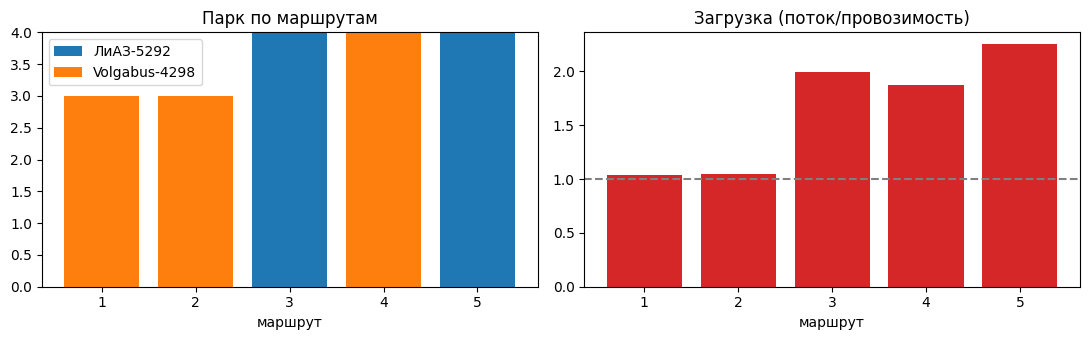

In [25]:
def fleet_load_table(routes, label=""):
    Tavg, det = evaluate_sue(routes, detail=True)
    rows=[]
    for i, r in enumerate(routes):
        veh = det['veh'][i]
        rows.append(dict(Маршрут=i+1, Остановок=len(r),
            Машин=len(veh), ЛиАЗ=sum(1 for v in veh if v==117), Volgabus=sum(1 for v in veh if v==49),
            Интервал_мин=round(det['headway'][i]/60,1),
            Поток_пасс=int(round(det['route_flow'][i])),
            Провозимость_пасс=int(round(det['cap'][i]*P['peak_hours'])),
            Загрузка=round(det['load'][i],2)))
    df = pd.DataFrame(rows)
    print(f"{label} T_avg={Tavg/60:.2f} мин | обслужено {det['served_pct']:.1f}% | макс загрузка {det['load'].max():.2f}")
    display(df)
    fig, ax = plt.subplots(1,2, figsize=(11,3.5))
    x=df['Маршрут']
    ax[0].bar(x, df['ЛиАЗ'], label='ЛиАЗ-5292', color='tab:blue')
    ax[0].bar(x, df['Volgabus'], bottom=df['ЛиАЗ'], label='Volgabus-4298', color='tab:orange')
    ax[0].set_title('Парк по маршрутам'); ax[0].set_xlabel('маршрут'); ax[0].legend(); ax[0].set_xticks(x)
    ax[1].bar(x, df['Загрузка'], color=np.where(df['Загрузка']>1,'tab:red','tab:green'))
    ax[1].axhline(1.0, ls='--', color='gray'); ax[1].set_title('Загрузка (поток/провозимость)')
    ax[1].set_xlabel('маршрут'); ax[1].set_xticks(x)
    plt.tight_layout(); plt.show()
    return df
print("Примечание: столбцы 'Поток' и 'Загрузка' иллюстративны (зависят от commuter_share=%.2f);"
      % P['commuter_share'])
print("оптимизируемая метрика T_avg при crowd=False от масштаба спроса не зависит.")
_ = fleet_load_table(sel_sue, "SUE-сеть:")

## 12. Дополнительные метрики (взвешенные перцентили; как в бейзлайне)

In [26]:
Tavg, det = evaluate_sue(sel_sue, detail=True); ent_time = det['ent_time']
def wpct(values, weights, q):
    o=np.argsort(values); v,w=values[o],weights[o]; cw=np.cumsum(w); cw=cw/cw[-1]
    return float(np.interp(q/100, cw, v))
served = ent_time < P['unserved_penalty_s']
metrics = pd.DataFrame([
    dict(Метрика='T_avg (среднее)', Значение_мин=round(Tavg/60,2)),
    dict(Метрика='Медиана', Значение_мин=round(wpct(ent_time,POP,50)/60,2)),
    dict(Метрика='P90', Значение_мин=round(wpct(ent_time,POP,90)/60,2)),
    dict(Метрика='Minimax (обслуженные)', Значение_мин=round(ent_time[served].max()/60,2)),
])
print(f"Неохваченных: {(~served).sum()} подъездов ({POP[~served].sum()/POP.sum()*100:.1f}% населения)")
display(metrics)

Неохваченных: 0 подъездов (0.0% населения)


,Метрика,Значение_мин
0,T_avg (среднее),13.61
1,Медиана,13.18
2,P90,17.60
3,Minimax (обслуженные),21.12


## 13. Экспорт маршрутов SUE-сети в GeoPackage (для QGIS)

In [27]:
def route_polyline(route):
    node_seq = [board_nodes[s] for s in route] + [metro_nodes[0]]; coords=[]
    for a, b in zip(node_seq[:-1], node_seq[1:]):
        try: path = nx.shortest_path(G, a, b, weight='time')
        except nx.NetworkXNoPath: continue
        coords += path if not coords else path[1:]
    return LineString(coords) if len(coords)>=2 else None
rows=[dict(route_id=i+1, n_stops=len(r), geometry=route_polyline(r)) for i,r in enumerate(sel_sue) if route_polyline(r)]
routes_gdf = gpd.GeoDataFrame(rows, crs=CRS)
routes_gdf.to_file(PATHS['out'], layer='routes', driver='GPKG')
served_idx = sorted(set(s for r in sel_sue for s in r))
board.iloc[served_idx].to_file(PATHS['out'], layer='served_stops', driver='GPKG')
print("Сохранено", PATHS['out'], "—", len(routes_gdf), "маршрутов,", len(served_idx), "остановок")

Сохранено C:\Users\georg\NIS\Curse_work_2026\sue_routes_v2.gpkg — 5 маршрутов, 21 остановок


## 14. Визуализация в Python

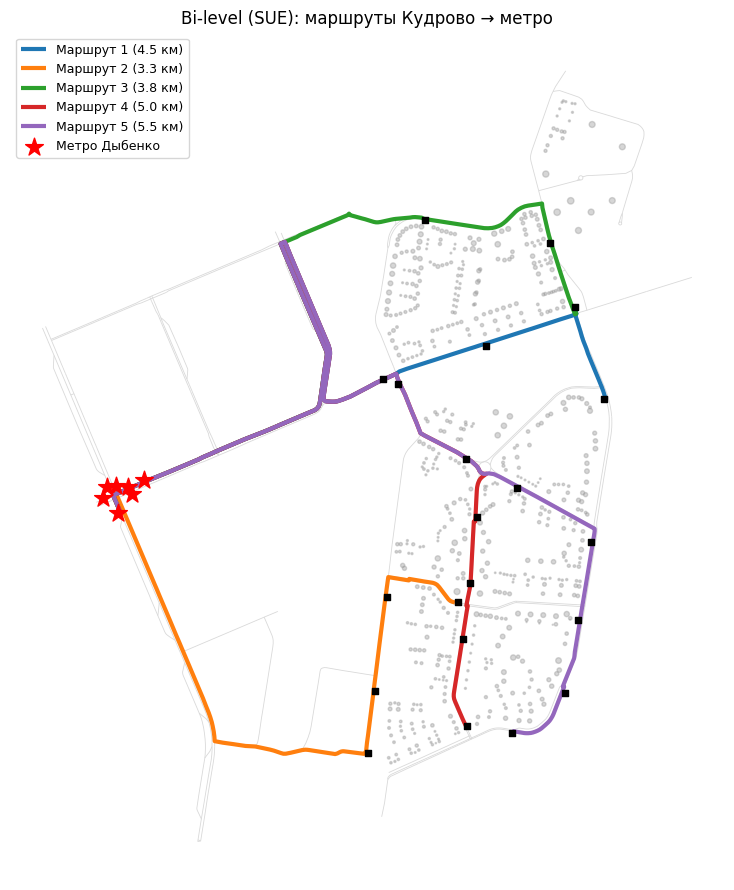

In [28]:
roads = gpd.read_file(PATHS['roads'], layer='doroga_for_busiki').to_crs(CRS)
fig, ax = plt.subplots(figsize=(11,9))
roads.plot(ax=ax, color='0.85', lw=0.6, zorder=1)
ent.plot(ax=ax, color='0.6', markersize=ent['population']/30, alpha=0.4, zorder=2)
cmap = plt.cm.tab10
for i,(_,r) in enumerate(routes_gdf.iterrows()):
    gpd.GeoSeries([r.geometry], crs=CRS).plot(ax=ax, color=cmap(i%10), lw=3, zorder=4,
        label=f"Маршрут {r['route_id']} ({r.geometry.length/1000:.1f} км)")
board.iloc[served_idx].plot(ax=ax, color='black', markersize=22, marker='s', zorder=5)
metro.plot(ax=ax, color='red', markersize=180, marker='*', zorder=6, label='Метро Дыбенко')
ax.legend(loc='upper left', fontsize=9); ax.set_title('Bi-level (SUE): маршруты Кудрово → метро')
ax.set_axis_off(); plt.tight_layout(); plt.show()

## 15. Что показывает эксперимент (для выводов курсовой)
- **Поведение пассажиров меняет, какая сеть «лучше».** При вероятностном (логит) выборе и учёте
  того, что несколько маршрутов на остановке складывают частоты, оптимальная сеть отличается
  от той, что выбирает наивный `argmin`.
- **SUE-сеть structurally иная.** Она сама **чаще сводит маршруты на общие остановки** (выше
  «Остановок с >1 маршрутом»), потому что видит выгоду от суммирования частот — `argmin` такую
  конфигурацию не распознаёт как лучшую. Это и даёт меньшее `T_avg` и лучшее покрытие.
- **Цена стохастичности.** Логит-выбор (часть людей идёт не на абсолютно лучшую остановку) даёт
  небольшую, но измеримую надбавку к `T_avg` относительно детерминированного выбора — это
  плата за реалистичность.
- **Метрика устойчива к приближённости населения.** При `crowd=False` `T_avg` не зависит от
  доли коммьютеров (sqrt-правило раздачи парка инвариантно к масштабу), поэтому грубость оценки
  населения не влияет на главный результат — влияет лишь на иллюстративные потоки/загрузки.
- **Задел под GNN+RL.** `evaluate_sue` — уже полноценный *симулятор среды* со стохастическим
  поведением; обучать RL-политику нужно против него, иначе она оптимизирует упрощённый мир.

### Оговорки (ограничения модели)
- Параметры поведения ($\theta$, $w_0$) взяты из диапазонов литературы, не откалиброваны на
  местных данных. Полезен анализ чувствительности по $\theta$.
- Выбор остановки ограничен 3 ближайшими из OD-матрицы.
- Пересадок нет (одна станция-сток) — модель оптимальной стратегии в «одностоковом» виде.
- Провозимость/давка в фокус не входят и выключены (`crowd=False`); включаются одной строкой
  как отдельный сценарий.


In [29]:
# Существующая сеть под SUE-логит, top-3
ROUTES_EXISTING = [
    [13,38,14,9,10,19,28,27,7,25,43,42,3,2],
    [40,24,16,23,15,22],
    [17,29,8,26,42,3,2],
    [37,28,27,30,18,21,5],
]

T_existing_sue3 = evaluate_sue(ROUTES_EXISTING, crowd=False) / 60
print(f"Существующая сеть | SUE-логит top-3: T_avg = {T_existing_sue3:.2f} мин")
print(f"Для сравнения: SUE-ГА = 13.61 мин, бейзлайн SUE (жадный) = 14.06 мин")

Существующая сеть | SUE-логит top-3: T_avg = 15.58 мин
Для сравнения: SUE-ГА = 13.61 мин, бейзлайн SUE (жадный) = 14.06 мин


C:\Users\georg\AppData\Local\Temp\ipykernel_29432\1247505794.py:50: RuntimeWarning: All-NaN slice encountered
  shift = np.nanmin(np.where(served,U,np.nan), axis=1, keepdims=True)
C:\Users\georg\AppData\Local\Temp\ipykernel_29432\1247505794.py:52: RuntimeWarning: invalid value encountered in divide
  prob = np.where(Z>0, ex/Z, 0.0); has = (Z[:,0]>0)
